# Data Preprocessing and Modeling

In [9]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)


# Load dataset
df = pd.read_csv("./data/faang_stock_prices.csv")


# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])


# Sort data
df = df.sort_values(["Ticker", "Date"])


# Filter Apple stock only
company_df = df[df["Ticker"] == "AAPL"].copy()

company_df = company_df.sort_values("Date")


# Select features
features = ["Open", "High", "Low", "Close"]

data = company_df[features].values


# Create sequences
window_size = 20

X = []
y = []

for i in range(len(data) - window_size):

    # Previous 20 days
    X.append(
        data[i:i+window_size]
    )

    # Next day's closing price
    y.append(
        data[i+window_size][3]
    )


# Convert to arrays
X = np.array(X)

y = np.array(y)


# Train/test split
split_index = int(len(X) * 0.80)

X_train = X[:split_index]

X_test = X[split_index:]

y_train = y[:split_index]

y_test = y[split_index:]


# Scale feature data
x_scaler = MinMaxScaler()


# Reshape training data
X_train_reshaped = X_train.reshape(
    -1,
    X_train.shape[2]
)

# Scale training data
X_train_scaled = x_scaler.fit_transform(
    X_train_reshaped
)

# Reshape back
X_train_scaled = X_train_scaled.reshape(
    X_train.shape
)


# Reshape testing data
X_test_reshaped = X_test.reshape(
    -1,
    X_test.shape[2]
)

# Scale testing data
X_test_scaled = x_scaler.transform(
    X_test_reshaped
)

# Reshape back
X_test_scaled = X_test_scaled.reshape(
    X_test.shape
)


# Scale target values
y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1,1)
)

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1,1)
)


# Flatten data for Linear Regression
# and Random Forest

X_train_flat = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    -1
)

X_test_flat = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    -1
)


# --------------------------------
# Linear Regression Model
# --------------------------------

linear_model = LinearRegression()

linear_model.fit(
    X_train_flat,
    y_train_scaled
)

linear_predictions = linear_model.predict(
    X_test_flat
)

linear_predictions = y_scaler.inverse_transform(
    linear_predictions
)


# --------------------------------
# Random Forest Model
# --------------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_flat,
    y_train_scaled.ravel()
)

rf_predictions = rf_model.predict(
    X_test_flat
)

rf_predictions = rf_predictions.reshape(-1,1)

rf_predictions = y_scaler.inverse_transform(
    rf_predictions
)


# --------------------------------
# LSTM Model
# --------------------------------

lstm_model = Sequential()

# First LSTM layer
lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(window_size, 4)
    )
)

# Dropout layer
lstm_model.add(Dropout(0.2))

# Second LSTM layer
lstm_model.add(LSTM(32))

# Dropout layer
lstm_model.add(Dropout(0.2))

# Output layer
lstm_model.add(Dense(1))


# Compile model
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()


# Train model
history = lstm_model.fit(

    X_train_scaled,
    y_train_scaled,

    epochs=40,
    batch_size=32,

    validation_data=(
        X_test_scaled,
        y_test_scaled
    )
)


# Make predictions
lstm_predictions = lstm_model.predict(
    X_test_scaled
)

lstm_predictions = y_scaler.inverse_transform(
    lstm_predictions
)


# Convert actual prices back
y_test_actual = y_scaler.inverse_transform(
    y_test_scaled
)


# --------------------------------
# Evaluation Metrics
# --------------------------------

# Linear Regression metrics
linear_mae = mean_absolute_error(
    y_test_actual,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        linear_predictions
    )
)


# Random Forest metrics
rf_mae = mean_absolute_error(
    y_test_actual,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        rf_predictions
    )
)


# LSTM metrics
lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_predictions
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 20, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0165 - val_loss: 0.0163
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0042 - val_loss: 0.0092
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0037 - val_loss: 0.0086
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0038 - val_loss: 0.0119
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0034 - val_loss: 0.0072
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0031 - val_loss: 0.0085
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0031 - val_loss: 0.0040
Epoch 8/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0029 - val_loss: 0.0044
Epoch 9/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0028 - val_loss: 0.0058
Epoch 10/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0029 - val_loss: 0.0150
Epoch 11/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0031 - val_loss: 0.0112
Epoch 12/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0

In [10]:
# Comparison table
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "LSTM"
    ],

    "MAE": [
        round(linear_mae,2),
        round(rf_mae,2),
        round(lstm_mae,2)
    ],

    "RMSE": [
        round(linear_rmse,2),
        round(rf_rmse,2),
        round(lstm_rmse,2)
    ]
})

print("\nComparison Table")
results


Comparison Table


,Model,MAE,RMSE
0,Linear Regression,2.70,3.89
1,Random Forest,31.59,40.03
2,LSTM,14.17,16.16


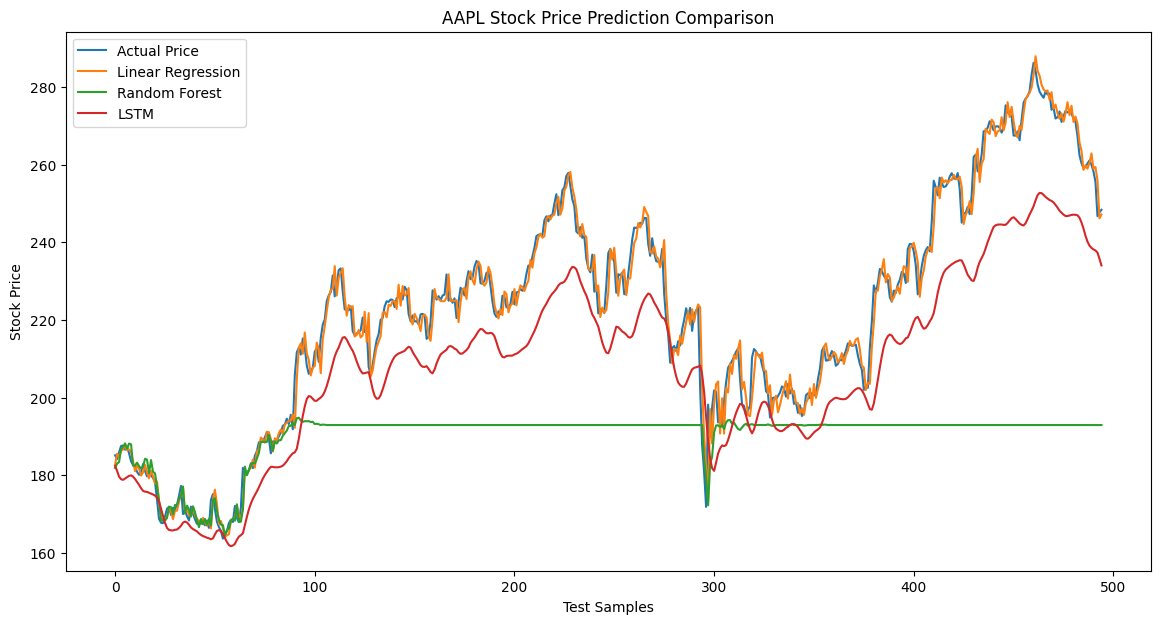

In [11]:
# Plot predictions
plt.figure(figsize=(14,7))

plt.plot(
    y_test_actual,
    label="Actual Price"
)

plt.plot(
    linear_predictions,
    label="Linear Regression"
)

plt.plot(
    rf_predictions,
    label="Random Forest"
)

plt.plot(
    lstm_predictions,
    label="LSTM"
)

plt.title("AAPL Stock Price Prediction Comparison")

plt.xlabel("Test Samples")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [6]:
# Prediction comparison table

comparison_df = pd.DataFrame({

    "Actual Price": y_test_actual.flatten(),

    "Linear Regression Prediction": (
        linear_predictions.flatten()
    ),

    "Random Forest Prediction": (
        rf_predictions.flatten()
    ),

    "LSTM Prediction": (
        lstm_predictions.flatten()
    )
})


# Round values
comparison_df = comparison_df.round(2)


# Display predictions
print("\nPrediction Comparison\n")
comparison_df.head(20)


Prediction Comparison



,Actual Price,Linear Regression Prediction,Random Forest Prediction,LSTM Prediction
0,185.11,182.67,181.86,187.679993
1,184.11,185.49,182.98,186.419998
2,185.92,184.76,183.39,184.949997
3,187.53,186.28,186.74,184.210007
4,187.64,186.64,187.24,183.899994
5,186.56,187.66,188.18,184.100006
6,187.32,186.41,186.87,184.339996
7,185.64,186.61,188.15,184.630005
8,183.54,185.94,187.93,184.750000
9,182.66,183.58,182.40,184.460007
